<a href="https://colab.research.google.com/github/palarunava/machine-learning-courses/blob/main/tensorflow-developer-professional-certificate/convolution-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST Dataset

The [Fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) is a collection of grayscale 28x28 pixel clothing images. Each image is associated with a label as shown in this table.

| Label | Description |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

This dataset is available directly in the [tf.keras.datasets](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) API and you load it like this:

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of training samples: (60000, 28, 28)
Number of test samples: 10000
Training Sample: 13635
LABEL: 9

IMAGE PIXEL ARRAY:

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   6   5   2   1   0   0   0   0   0 165  40]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 118  11]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   8 143  24   0   0   0   0   0   0   0 197  67]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0 188 246 227 222 177 108  76  76 105 173 204  43]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   2   0  72 205 193 218 216 234 255 243 244 224 207 180   6]
 [  0   0   0   0   0   0   0   0   0   0   0   0   2   0   0 255 215 227 232 212 195 235 251 237 190 202 176 

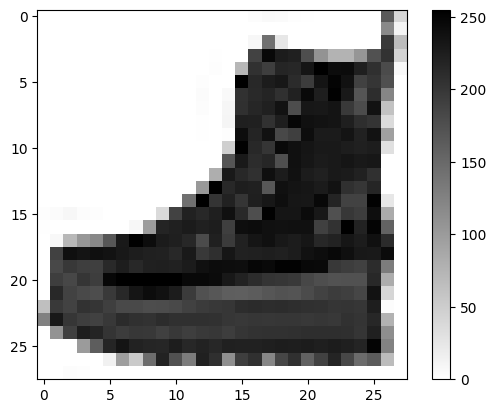

In [ ]:
fmnist = tf.keras.datasets.fashion_mnist

# Load the training and test split of the Fashion MNIST dataset
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()
print(f'Number of training samples: {training_images.shape}')
print(f'Number of test samples: {test_images.shape[0]}')

# You can put between 0 to 59999 here
index = np.random.randint(0, 59999)

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'Training Sample: {index + 1}')
print(f'LABEL: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n\n{training_images[index]}\n\n')

# Visualize the image using the default colormap (viridis)
# Arg
#   cmp: colormap = 'viridis' by default
plt.imshow(training_images[index], cmap='binary')
plt.colorbar()
plt.show()

# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [ ]:
iterations = 5

# Build the classification model
model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(28,28,1)),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  # Same output layers
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

# Print the model summary
model.summary()

model.compile(
  optimizer = tf.optimizers.Adam(),
  loss = 'sparse_categorical_crossentropy',
  metrics=['accuracy']
)

history = model.fit(training_images, training_labels, epochs=iterations)
print(f'History: {history}')

test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_accuracy}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7840 - loss: 0.6022
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8900 - loss: 0.3029
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9059 - loss: 0.2542
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9175 - loss: 0.2173
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9291 - loss: 0.1877
History: <keras.src.callbacks.history.History object at 0x7ce756d94d10>
Test loss: 0.2585303485393524
Test accuracy: 0.9097999930381775


In [ ]:
# Set number of characters per row when printing
np.set_printoptions(
    linewidth=120,
    suppress=True,
    precision=4
)

# There are 10000 test samples
# Get the first 100 test samples
print(f'First 100 labels:\n\n{test_labels[:100]}')

# Display the sample indices for shoes
print(f'\nShoes: {[i for i in range(100) if test_labels[:100][i] == 9]}')

First 100 labels:

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3 8 8 3 3 8 0 7 5 7 9 6 1 3 7 6 7 2 1 2 2 4 4 5 8 2 2 8 4 8
 0 7 7 8 5 1 1 2 3 9 8 7 0 2 6 2 3 1 2 8 4 1 8 5 9 5 0 3 2 0 6 5 3 6 7 1 8 0 1 4 2]

Shoes: [0, 23, 28, 39, 68, 83]


Model layers:
[<Conv2D name=conv2d, built=True> <MaxPooling2D name=max_pooling2d, built=True> <Conv2D name=conv2d_1, built=True>
 <MaxPooling2D name=max_pooling2d_1, built=True> <Flatten name=flatten, built=True> <Dense name=dense, built=True>
 <Dense name=dense_1, built=True>]



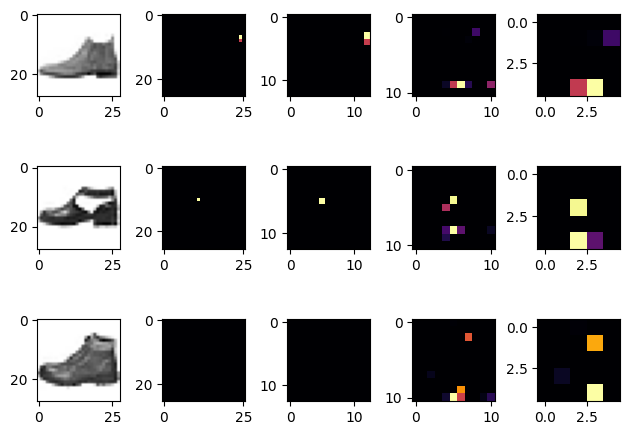

In [ ]:
shoes = [i for i in range(100) if test_labels[:100][i] == 9]
FIRST_IMAGE = shoes[0]
SECOND_IMAGE = shoes[1]
THIRD_IMAGE = shoes[2]

# We have configured 64 filters. Choose a number from 0-63.
CONVOLUTION_NUMBER = 10

layers_to_visualize = [tf.keras.layers.Conv2D, tf.keras.layers.MaxPooling2D]

print(f'Model layers:\n{np.array(model.layers)}\n')
layer_outputs = [layer.output for layer in model.layers if type(layer) in layers_to_visualize]
activation_model = tf.keras.models.Model(inputs = model.inputs, outputs = layer_outputs)

f, axarr = plt.subplots(3, len(layer_outputs) + 1)

# Plot the actual image
axarr[0,0].imshow(test_images[FIRST_IMAGE], cmap='binary')
axarr[0,0].grid(False)
axarr[1,0].imshow(test_images[SECOND_IMAGE], cmap='binary')
axarr[0,0].grid(False)
axarr[2,0].imshow(test_images[THIRD_IMAGE], cmap='binary')
axarr[0,0].grid(False)

for x in range(0, len(layer_outputs)):
    f1 = activation_model.predict(test_images[FIRST_IMAGE].reshape(1, 28, 28, 1), verbose=False)[x]
    axarr[0,x+1].imshow(f1[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[0,x+1].grid(False)

    f2 = activation_model.predict(test_images[SECOND_IMAGE].reshape(1, 28, 28, 1), verbose=False)[x]
    axarr[1,x+1].imshow(f2[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[1,x+1].grid(False)

    f3 = activation_model.predict(test_images[THIRD_IMAGE].reshape(1, 28, 28, 1), verbose=False)[x]
    axarr[2,x+1].imshow(f3[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[2,x+1].grid(False)

plt.tight_layout()

# Exploring Convolutions

In [ ]:
# Ascent image that you will work with from the SciPy library
from scipy.datasets import ascent

In [ ]:
# load the ascent image
ascent_image = ascent()

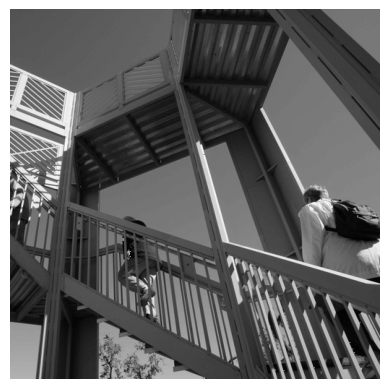

In [ ]:
# Visualize the image
plt.grid(False)
plt.gray()
plt.axis('off')
plt.imshow(ascent_image)
plt.show()

In [ ]:
# Copy image to a numpy array
image_transformed = np.copy(ascent_image)

# Get the dimensions of the image
size_x = image_transformed.shape[0]
size_y = image_transformed.shape[1]

print(f"image_transformed has shape: {size_x, size_y}")

image_transformed has shape: (512, 512)


In [ ]:
# Experiment with different values and see the effect
filter = [[0, 1, 0], [1, -4, 1], [0, 1, 0]]

# A couple more filters to try for fun!
# filter = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]
# filter = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]

# If all the digits in the filter don't add up to 0 or 1, you
# should probably do a weight to get it to do so
# so, for example, if your weights are 1,1,1 1,2,1 1,1,1
# They add up to 10, so you would set a weight of .1 if you want to normalize them
weight  = 1

In [ ]:
ascent_image = ascent_image.astype(np.int8)

Effect of applying *Convolution* filters

In [ ]:
# Change the element type of the image to resolve the following error:
# Error:
#     OverflowError: Python integer -4 out of bounds for uint8
ascent_image = ascent_image.astype(np.int64)

# Iterate over the image
for x in range(1, size_x-1):
    for y in range(1, size_y-1):
        convolution = 0.0
        convolution = convolution + (ascent_image[x-1, y-1] * filter[0][0])
        convolution = convolution + (ascent_image[x-1, y] * filter[0][1])
        convolution = convolution + (ascent_image[x-1, y+1] * filter[0][2])
        convolution = convolution + (ascent_image[x, y-1] * filter[1][0])
        convolution = convolution + (ascent_image[x, y] * filter[1][1])
        convolution = convolution + (ascent_image[x, y+1] * filter[1][2])
        convolution = convolution + (ascent_image[x+1, y-1] * filter[2][0])
        convolution = convolution + (ascent_image[x+1, y] * filter[2][1])
        convolution = convolution + (ascent_image[x+1, y+1] * filter[2][2])

        # Multiply by weight
        convolution = convolution * weight

        # Check the boundaries of the pixel values
        if(convolution < 0):
            convolution = 0
        if(convolution > 255):
            convolution = 255

        # Load into the transformed image
        image_transformed[x, y] = convolution

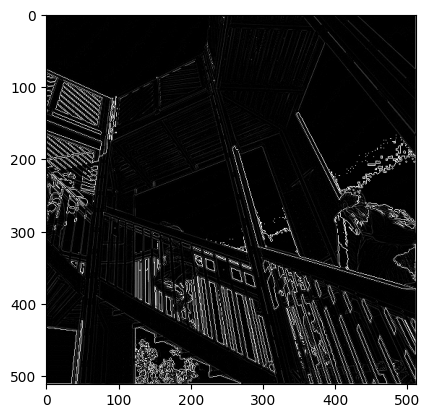

In [ ]:
# Plot the image. Note the size of the axes -- you will compare this later after max pooling
plt.gray()
plt.grid(False)
plt.imshow(image_transformed)
plt.show()

Effect of Max Pooling

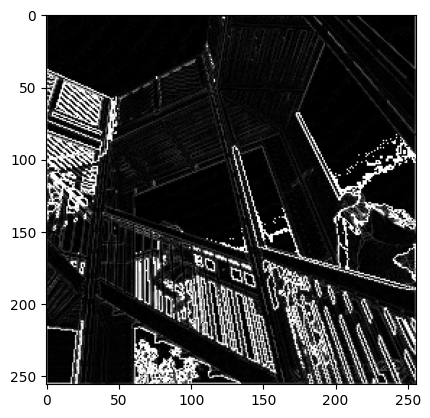

In [ ]:
# Assign dimensions half the size of the original image
new_x = int(size_x / 2)
new_y = int(size_y / 2)

# Create blank image with reduced dimensions
newImage = np.zeros((new_x, new_y))

# Iterate over the image
for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):

        # Store all the pixel values in the (2,2) pool
        pixels = []
        pixels.append(image_transformed[x, y])
        pixels.append(image_transformed[x+1, y])
        pixels.append(image_transformed[x, y+1])
        pixels.append(image_transformed[x+1, y+1])

        # Get only the largest value and assign to the reduced image
        newImage[int(x / 2), int(y / 2)] = max(pixels)

# Plot the image. Note the size of the axes -- it is now half of the image loaded earlier
plt.gray()
plt.grid(False)
plt.imshow(newImage)
plt.show()

# Fruits Classification with CNN

In [ ]:
import kagglehub
import os
import sys
import shutil

In [ ]:
# Download latest version
path = kagglehub.dataset_download("karimabdulnabi/fruit-classification10-class")

Using Colab cache for faster access to the 'fruit-classification10-class' dataset.


In [ ]:
#@title Copy data to a working directory and change all folder names to lowercase
def copy_data_and_rename_folders_to_lowercase(path):

    # Run this to create a copy of the input data.
    # This is needed so that we can rename the folder name to have consistent labels in train and test.
    # The original kaggle input directory is a read-only directory.
    DOWNLOAD_DIR = path
    WORKING_DIR = './data'

    # Delete working folder if already exists
    if os.path.exists(WORKING_DIR):
        shutil.rmtree(WORKING_DIR)

    # Copy data to working folder
    shutil.copytree(DOWNLOAD_DIR, WORKING_DIR)

    # This code renames all directory name to lower case recursively inside a directory.
    start_dir = WORKING_DIR + '/MY_data'

    # Walk the directory tree from bottom up
    for root, dirs, files in os.walk(start_dir, topdown=False):
        for dir_name in dirs:
            original_path = os.path.join(root, dir_name)
            new_name = dir_name.lower()
            new_path = os.path.join(root, new_name)

            # Rename only if the name has changed
            if original_path != new_path:
                try:
                    # Check if a directory with the new name already exists (case collision)
                    if not os.path.exists(new_path):
                        os.rename(original_path, new_path)
                        print(f"Renamed: {original_path} to {new_path}")
                    else:
                        print(f"Skipping: {original_path} (destination {new_path} already exists)")
                except OSError as e:
                    print(f"Error renaming {original_path}: {e}")

    return WORKING_DIR

In [ ]:
WORKING_DIR = copy_data_and_rename_folders_to_lowercase(path)

Renamed: ./data/MY_data/train/Banana to ./data/MY_data/train/banana
Renamed: ./data/MY_data/train/Apple to ./data/MY_data/train/apple


In [ ]:
TRAIN_DIR = WORKING_DIR + '/MY_data/train'
VALID_DIR = WORKING_DIR + '/MY_data/test'
TEST_DIR = WORKING_DIR + '/MY_data/predict'
print(f'Files in {TRAIN_DIR}: {os.listdir(TRAIN_DIR)}')
print(f'Files in {VALID_DIR}: {os.listdir(VALID_DIR)}')
print(f'Files in {TEST_DIR}: {os.listdir(TEST_DIR)}')

Files in ./data/MY_data/train: ['kiwi', 'mango', 'pinenapple', 'cherry', 'apple', 'watermelon', 'banana', 'strawberries', 'avocado', 'orange']
Files in ./data/MY_data/test: ['kiwi', 'mango', 'pinenapple', 'stawberries', 'cherry', 'apple', 'watermelon', 'banana', 'avocado', 'orange']
Files in ./data/MY_data/predict: ['77.jpeg', '9.jpeg', '22.jpeg', '0124.jpeg', 'img_191.jpeg', '33.jpeg', 'img_141.jpeg', '321.jpeg', '0122.jpeg', 'img_301.jpeg', '41.jpeg', '659.jpeg', 'img_11.jpeg', 'img_371.jpeg', 'img_411.jpeg', '66.jpeg', '012.jpeg', 'f2.jpeg', 'img_361.jpeg', 'f7.jpeg', '023.jpeg', '1.jpeg', 'img_171.jpeg', 'img_401.jpeg', 'img_21.jpeg', 'img_31.jpeg', 'f1.jpeg', '011.jpeg', '4.jpeg', '147.jpeg', 'f5.jpeg', '00.jpeg', 'img_41.jpeg', '3.jpeg', 'f0.jpeg', '68.jpeg', 'img_241.jpeg', 'img_421.jpeg', 'img_341.jpeg', '202.jpeg', 'img_01.jpeg', '99.jpeg', '0.jpeg', '65.jpeg', '365.jpeg', '2.jpeg', 'img_381.jpeg', 'img_121.jpeg']


In [ ]:
#@title Load a single image into a 3-D array
IMAGE_PATH = './data/MY_data/test/apple/img_1001.jpeg'
# 1. Load the image using Keras utility (returns a PIL Image instance)
# You can specify target_size to resize the image automatically
img = tf.keras.utils.load_img(IMAGE_PATH)

# 2. Convert the PIL image instance to a NumPy array
img_array = tf.keras.utils.img_to_array(img)

# The result is a 3D NumPy array (height, width, channels)
# print(type(img_array))
print(f'Path: {IMAGE_PATH}, Shape: {img_array.shape}')

Path: ./data/MY_data/test/apple/img_1001.jpeg, Shape: (225, 225, 3)


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels=None,              # no labels needed
    image_size=(224, 224),    # must match model input
    batch_size=32,            # batch size
    shuffle=False             # keep file order
)

Found 2301 files belonging to 10 classes.
Found 1025 files belonging to 10 classes.
Found 48 files.


In [ ]:
#@title Looking at an image and its label from the training dataset
class_names = train_dataset.class_names
print(class_names)

target_class = "banana"   # change to your class
class_index = class_names.index(target_class)

filtered_ds = train_dataset.filter(
    lambda x, y: tf.equal(tf.argmax(y, axis=1), class_index)[0]
)

images, labels = next(iter(filtered_ds))

print(images.shape)   # (32, 224, 224, 3)
print(labels.shape)   # (32, num_classes)

image = images[0]
label = labels[0]

print(image)   # (224, 224, 3)
print(label)         # one-hot vector

['apple', 'avocado', 'banana', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
(32, 224, 224, 3)
(32, 10)
tf.Tensor(
[[[ 44.      19.       0.    ]
  [ 44.      19.       0.    ]
  [ 44.      19.       0.    ]
  ...
  [207.1518  72.1518   6.4554]
  [207.5089  73.9822   5.0713]
  [207.      75.8304   0.1696]]

 [[ 45.25    20.25     0.625 ]
  [ 45.25    20.25     0.625 ]
  [ 45.25    20.25     0.625 ]
  ...
  [208.1172  72.0569   5.3003]
  [206.8839  73.3572   4.4463]
  [206.894   75.2054   0.0636]]

 [[ 47.125   21.75     2.875 ]
  [ 47.125   21.75     2.875 ]
  [ 47.125   21.75     2.875 ]
  ...
  [208.3783  71.1931   3.1072]
  [206.1406  72.0413   3.3079]
  [205.769   74.3917   0.    ]]

 ...

 [[ 22.1786   3.5536   0.4877]
  [ 27.2812   8.4654   3.4475]
  [ 28.2578   9.2578   2.4096]
  ...
  [215.75   158.6729 127.2913]
  [214.2767 151.8035 123.6696]
  [209.74   144.5982 117.2846]]

 [[ 25.115    6.115    2.115 ]
  [ 28.952    9.952    4.9342]
  [ 27

In [ ]:
#@title Looking at an image and its label from the validation dataset
class_names = validation_dataset.class_names
print(class_names)

target_class = "banana"   # change to your class
class_index = class_names.index(target_class)

filtered_ds = train_dataset.filter(
    lambda x, y: tf.equal(tf.argmax(y, axis=1), class_index)[0]
)

images, labels = next(iter(filtered_ds))

print(images.shape)   # (32, 224, 224, 3)
print(labels.shape)   # (32, num_classes)

image = images[0]
label = labels[0]

print(image)   # (224, 224, 3)
print(label)         # one-hot vector

['apple', 'avocado', 'banana', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'stawberries', 'watermelon']
(32, 224, 224, 3)
(32, 10)
tf.Tensor(
[[[230.1786 156.8616  10.0893]
  [187.654  122.0446   1.9754]
  [163.1674 108.4286   0.5692]
  ...
  [228.5692 181.       8.4153]
  [226.0246 179.683    1.7076]
  [222.3416 176.3416   0.    ]]

 [[246.3683 175.7054  26.0313]
  [204.1984 139.81     8.6632]
  [154.7989 102.2364   0.1563]
  ...
  [237.71   188.5782  21.1945]
  [235.7566 185.3102  19.4017]
  [220.5962 170.2435   5.0314]]

 [[253.854  184.5042  28.9737]
  [227.9501 166.1801  20.931 ]
  [180.1458 129.4918   4.8151]
  ...
  [230.7801 179.3463  21.55  ]
  [225.0066 169.0378  25.7278]
  [201.8025 145.4632   4.5324]]

 ...

 [[249.8213 194.5066  17.9754]
  [243.201  190.0001  17.8171]
  [238.8369 188.5712  21.9909]
  ...
  [252.3453 244.4793  42.841 ]
  [253.0446 240.7143  35.7835]
  [253.5424 240.3727  34.9152]]

 [[253.4576 199.4464  19.2188]
  [246.9375 194.4598  17.846 ]
  [243.

In [ ]:
rescale_layer = tf.keras.layers.Rescaling(1./255)

train_dataset_scaled = train_dataset.map(lambda image, label: (rescale_layer(image), label))
validation_dataset_scaled = validation_dataset.map(lambda image, label: (rescale_layer(image), label))
test_dataset_scaled = test_dataset.map(lambda image: (rescale_layer(image)))

In [ ]:
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE

train_dataset_final = (
    train_dataset_scaled
        .cache()
        .shuffle(SHUFFLE_BUFFER_SIZE)
        .prefetch(PREFETCH_BUFFER_SIZE)
)

validation_dataset_final = (
    validation_dataset_scaled
        .cache()
        .shuffle(SHUFFLE_BUFFER_SIZE)
        .prefetch(PREFETCH_BUFFER_SIZE)
)

test_dataset_final = (
    test_dataset_scaled
        .cache()
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 922,282 (3.52 MB)

 Trainable params: 922,282 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - accuracy: 0.1645 - loss: 2.1764 - val_accuracy: 0.2800 - val_loss: 1.7798
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.3948 - loss: 1.5416 - val_accuracy: 0.4361 - val_loss: 1.5106
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4597 - loss: 1.3881 - val_accuracy: 0.4644 - val_loss: 1.4248
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5000 - loss: 1.3218 - val_accuracy: 0.5083 - val_loss: 1.3741
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5433 - loss: 1.2270 - val_accuracy: 0.4946 - val_loss: 1.5899
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5859 - loss: 1.1153 - val_accuracy: 0.5483 - val_loss: 1.2573
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6506 - loss: 0.9526 - val_accuracy: 0.4771 - val_loss: 1.3877
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6735 - loss: 0.9095 - val_accuracy: 0.5463 -

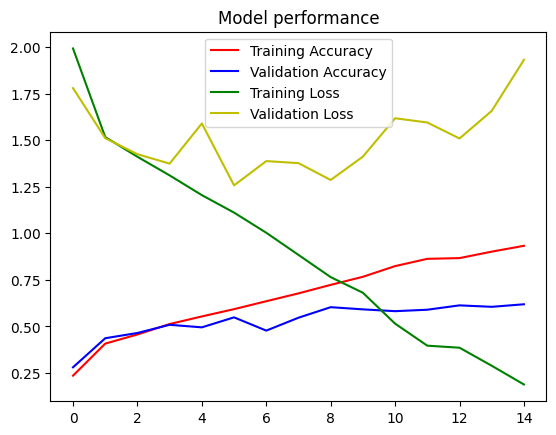

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 855ms/step


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(224,224,3)),

    # 1st convolution
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'), # 222,222,64
    tf.keras.layers.MaxPooling2D(2,2), # 111,111,3

    # 2nd convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'), # 109,109,64
    tf.keras.layers.MaxPooling2D(2,2), # 55,55,3

    # 3rd convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'), # 222,222,3
    tf.keras.layers.MaxPooling2D(2,2), # 111,111,3

    # 4th convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'), # 109,109,3
    tf.keras.layers.MaxPooling2D(2,2), # 55,55,3

    # 5th convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'), # 222,222,3
    tf.keras.layers.MaxPooling2D(2,2), # 111,111,3

    # Same output layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer = tf.optimizers.Adam(),
    # optimizer = tf.optimizers.RMSprop(learning_rate=0.001),
    loss = 'categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset_final,
    validation_data=validation_dataset_final,
    epochs=15 #,
    # verbose=2 # "auto", 0, 1, or 2. Verbosity mode. 0 = silent, 1 = progress bar, 2 = single line. "auto" becomes 1 for most cases.
)

# Plot model performance
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.plot(epochs, loss, 'g', label='Training Loss')
plt.plot(epochs, val_loss, 'y', label='Validation Loss')

plt.title('Model performance')

plt.legend(loc=0)
plt.show()

# Run predictions
predictions = model.predict(test_dataset_final)

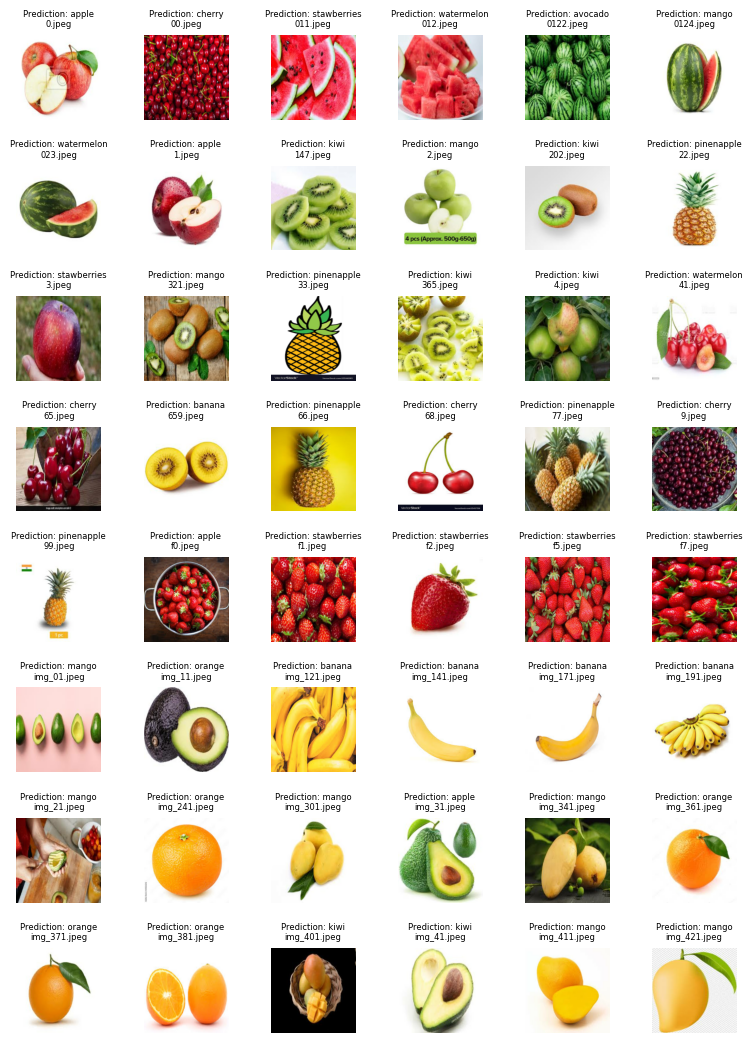

In [ ]:
class_names = validation_dataset.class_names
file_paths = test_dataset.file_paths

# num_images = predictions.shape[0]
num_images = 48
num_rows = 8
num_images_per_row = 6

f, axarr = plt.subplots(num_rows, num_images_per_row, figsize=(15,10))

i = 0
j = 0
k = 0
for batch in test_dataset_final:
    for image in batch:
        predicted_class = class_names[np.argmax(predictions[k])]
        axarr[i,j].imshow(image)
        axarr[i,j].set_title(f'Prediction: {predicted_class}\n{file_paths[k].split('/')[-1]}', fontsize=6)
        axarr[i,j].axis('off')
        k += 1
        j += 1
        if j >= num_images_per_row:
            j = 0
            i += 1

plt.subplots_adjust(
    left=0.02,
    right=0.5,
    top=1.0,
    bottom=0.0,
    wspace=0.5,   # horizontal gap
    hspace=0.5    # vertical gap
)

In [ ]:
model.save('fruit_classification_model.keras')

#Troubleshooting your model's performance - Bias and Variance

J_train $\uparrow$, J_cv $\uparrow$ - High Bias (Underfits)  
J_train $\downarrow$, J_cv $\uparrow$ = High Variance (Overfits)  
J_train $\downarrow$, J_cv $\downarrow$ = Good  

###How to solve?
High Bias:
* Try getting additional features
* Try adding polynomial features (x^2, x^3, etc.)
* Try decreasing lambda (regularization parameter)
* Try a bigger neural network (more hidden layers, layers with more number of neurons)

High variance:
* Get more training examples
* Try smaller sets of features
* Try increasing lambda (regularization parameter)

#Measuring your model's performance

###Confusion matrix:

| <u>Actual</u><br>Prediction | (A) 1 | (A) 0 |
|:-:|:-:|:-:|
| (P) 1    | (TP)<br>True<br>Positives | (FP)<br>False<br>Positives |
| (P) 0    | (FN)<br>False<br>Neagatives | (TN)<br>True<br>Neagatives |

Precision (P) = Of all training samples that were predicted true, what fraction were actually true
$$
Precision \;(P) = \frac{TP}{TP + FP}
$$

Recall = Of all training samples that were actually true, what fraction were predicted true
$$
Recall \;(R) = \frac{TP}{TP + FN}
$$
F_1 score is the harmonic mean of Precision (P) and Recall (R)
$$
F_1 = \frac{1}{\frac{1}{2}(\frac{1}{P} + \frac{1}{R})} = \frac{2PR}{P + R}
$$